# LSTM-Autoencoder untuk Deteksi Anomali (CSE-CICIDS-2018)


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
)
import matplotlib.pyplot as plt
import time
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.10.0+cu128


## 2. Load dan Analisis Dataset

In [2]:
SELECTED_COLUMNS = [
    "Dst Port",
    "Fwd Pkt Len Min",
    "Flow Pkts/s",
    "Bwd Pkts/s",
    "Fwd IAT Min",
    "ECE Flag Cnt",
    "ACK Flag Cnt",
    "Fwd Seg Size Min",
    "Fwd Act Data Pkts",
    "Idle Std",
    "Label",
]

FEATURE_COLUMNS = SELECTED_COLUMNS[:-1]  # 10 fitur (tanpa Label)

print(f"Fitur yang digunakan ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")
print(f"Membaca dataset...")

dataset = pd.read_csv("02-14-2018.csv", usecols=SELECTED_COLUMNS)
print(f"Shape awal: {dataset.shape}")
print(f"\nDistribusi Label:\n{dataset['Label'].value_counts()}")
print(f"\nMissing values per kolom:\n{dataset.isnull().sum().to_string()}")

Fitur yang digunakan (10): ['Dst Port', 'Fwd Pkt Len Min', 'Flow Pkts/s', 'Bwd Pkts/s', 'Fwd IAT Min', 'ECE Flag Cnt', 'ACK Flag Cnt', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Idle Std']
Membaca dataset...
Shape awal: (1048575, 11)
Shape awal: (1048575, 11)

Distribusi Label:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

Missing values per kolom:
Dst Port             0
Fwd Pkt Len Min      0
Flow Pkts/s          0
Fwd IAT Min          0
Bwd Pkts/s           0
ACK Flag Cnt         0
ECE Flag Cnt         0
Fwd Act Data Pkts    0
Fwd Seg Size Min     0
Idle Std             0
Label                0

Distribusi Label:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

Missing values per kolom:
Dst Port             0
Fwd Pkt Len Min      0
Flow Pkts/s          0
Fwd IAT Min          0
Bwd Pkts/s           0
ACK Flag Cnt         0
ECE Flag Cnt         0
Fwd Act Data Pkts    

## 3. Preprocessing: Bersihkan Missing Data & Inf

In [3]:
for col in FEATURE_COLUMNS:
    dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(dataset)
dataset.dropna(subset=FEATURE_COLUMNS, inplace=True)
rows_after = len(dataset)

print(f"Rows sebelum cleaning: {rows_before:,}")
print(f"Rows setelah cleaning:  {rows_after:,}")
print(f"Rows dibuang:          {rows_before - rows_after:,}")
print(f"\nDistribusi Label setelah cleaning:\n{dataset['Label'].value_counts()}")
print(f"\nKonfirmasi missing values: {dataset[FEATURE_COLUMNS].isnull().sum().sum()}")

Rows sebelum cleaning: 1,048,575
Rows setelah cleaning:  1,044,751
Rows dibuang:          3,824

Distribusi Label setelah cleaning:
Label
Benign            663808
FTP-BruteForce    193354
SSH-Bruteforce    187589
Name: count, dtype: int64

Konfirmasi missing values: 0


## 4. Split Data: Train (Benign) & Test (Benign + Attack)

In [4]:
TRAIN_BENIGN_SIZE = 300_000

# Pisahkan Benign dan Attack
benign_data = dataset[dataset["Label"] == "Benign"].copy()
attack_data = dataset[dataset["Label"] != "Benign"].copy()

del dataset

# benign_data = benign_data.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_benign = benign_data.iloc[:TRAIN_BENIGN_SIZE]
test_benign = benign_data.iloc[TRAIN_BENIGN_SIZE:]

del benign_data

test_data = pd.concat([test_benign, attack_data], ignore_index=True)

del test_benign, attack_data

train_labels = np.zeros(len(train_benign))  # Semua 0 (normal)
test_labels = (test_data["Label"] != "Benign").astype(int).values

print(f"=== DATA SPLIT ===")
print(f"Train: {len(train_benign):,} rows (100% Benign)")
print(f"Test:  {len(test_data):,} rows")
print(f"  - Benign:         {(test_labels == 0).sum():,}")
print(f"  - Attack:         {(test_labels == 1).sum():,}")
print(f"\nTest label detail:\n{test_data['Label'].value_counts().to_string()}")

=== DATA SPLIT ===
Train: 300,000 rows (100% Benign)
Test:  744,751 rows
  - Benign:         363,808
  - Attack:         380,943

Test label detail:
Label
Benign            363808
FTP-BruteForce    193354
SSH-Bruteforce    187589


## 5. Feature Scaling (StandardScaler)

In [5]:
# Fit scaler hanya pada data training (Benign)
scaler = StandardScaler()

X_train = scaler.fit_transform(train_benign[FEATURE_COLUMNS].values).astype(np.float32)
X_test = scaler.transform(test_data[FEATURE_COLUMNS].values).astype(np.float32)

# Hapus DataFrame, simpan hanya array
del train_benign, test_data

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nX_train stats: mean={X_train.mean():.4f}, std={X_train.std():.4f}")
print(f"X_test stats:  mean={X_test.mean():.4f}, std={X_test.std():.4f}")

X_train shape: (300000, 10)
X_test shape:  (744751, 10)

X_train stats: mean=0.0000, std=1.0000
X_test stats:  mean=0.7343, std=3.2166


## 6. Buat Sequences untuk LSTM

LSTM membutuhkan input 3D: `(batch, seq_len, features)`.  
Kita bentuk window/sequence dari data tabular.

In [6]:
SEQ_LEN = 10  # Panjang sequence (window)

def create_sequences(data, seq_len):
    """Buat sliding window sequences dari data 2D."""
    sequences = []
    for i in range(0, len(data) - seq_len + 1, seq_len):
        sequences.append(data[i : i + seq_len])
    return np.array(sequences)

def create_sequences_with_labels(data, labels, seq_len):
    """Buat sequences + ambil label mayoritas per window."""
    sequences = []
    seq_labels = []
    for i in range(0, len(data) - seq_len + 1, seq_len):
        sequences.append(data[i : i + seq_len])
        # Label = 1 (attack) jika ada minimal 1 attack dalam window
        seq_labels.append(1 if labels[i : i + seq_len].sum() > 0 else 0)
    return np.array(sequences), np.array(seq_labels)

# Buat sequences
X_train_seq = create_sequences(X_train, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences_with_labels(X_test, test_labels, SEQ_LEN)

# Hapus array mentah
del X_train, X_test, test_labels

print(f"X_train_seq shape: {X_train_seq.shape}  (batch, seq_len, features)")
print(f"X_test_seq shape:  {X_test_seq.shape}")
print(f"y_test_seq shape:  {y_test_seq.shape}")
print(f"\nTest sequences - Normal: {(y_test_seq == 0).sum():,}, Attack: {(y_test_seq == 1).sum():,}")

X_train_seq shape: (30000, 10, 10)  (batch, seq_len, features)
X_test_seq shape:  (74475, 10, 10)
y_test_seq shape:  (74475,)

Test sequences - Normal: 36,380, Attack: 38,095


## 7. DataLoader

In [7]:
BATCH_SIZE = 256

train_tensor = torch.from_numpy(X_train_seq)
test_tensor = torch.from_numpy(X_test_seq)

train_loader = DataLoader(
    TensorDataset(train_tensor, train_tensor),  # input == target (autoencoder)
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

test_loader = DataLoader(
    TensorDataset(test_tensor, test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"Batch size:    {BATCH_SIZE}")

Train batches: 117
Test batches:  291
Batch size:    256


## 8. Definisi Model: LSTM-Autoencoder

**Arsitektur:**
- **Encoder**: LSTM multilayer → compress sequence menjadi latent vector
- **Decoder**: LSTM multilayer → reconstruct sequence dari latent vector
- **Output Layer**: Linear → proyeksi ke dimensi fitur asli

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (hidden, cell) = self.lstm(x)
        # hidden: (num_layers, batch, hidden_dim)
        return hidden, cell

class LSTMDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout=0.0):
        super().__init__()
        self.seq_len = None 
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_dim, output_dim)
    def forward(self, x, hidden, cell):
        # x: (batch, seq_len, input_dim) — repeated latent
        output, _ = self.lstm(x, (hidden, cell))
        # output: (batch, seq_len, hidden_dim)
        reconstruction = self.output_layer(output)
        # reconstruction: (batch, seq_len, output_dim)
        return reconstruction

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, dropout=0.0):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = LSTMEncoder(input_dim, hidden_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, num_layers, dropout)
        self.hidden_to_latent = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        hidden, cell = self.encoder(x)
        latent = self.hidden_to_latent(hidden[-1])  # (batch, latent_dim)
        decoder_input = latent.unsqueeze(1).repeat(1, seq_len, 1)  # (batch, seq_len, latent_dim)
        reconstruction = self.decoder(decoder_input, hidden, cell)
        return reconstruction, latent


# Hyperparameters
INPUT_DIM = len(FEATURE_COLUMNS)
HIDDEN_DIM = 64
LATENT_DIM = 32
NUM_LAYERS = 2
DROPOUT = 0.1

model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.1)
  )
  (decoder): LSTMDecoder(
    (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.1)
    (output_layer): Linear(in_features=64, out_features=10, bias=True)
  )
  (hidden_to_latent): Linear(in_features=64, out_features=32, bias=True)
)

Total parameters: 113,834


## 9. Training Loop

In [9]:
# Hyperparameters Training
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# History untuk plot
history = {"train_loss": [], "test_loss": []}


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        recon, _ = model(batch_x)
        loss = criterion(recon, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        recon, _ = model(batch_x)
        loss = criterion(recon, batch_y)
        total_loss += loss.item() * batch_x.size(0)
    return total_loss / len(loader.dataset)


print("=" * 60)
print(f"Training LSTM-Autoencoder | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}")
print("=" * 60)

best_test_loss = float("inf")
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    scheduler.step(test_loss)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    epoch_time = time.time() - epoch_start

    # Simpan model terbaik
    marker = ""
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "new_lstm_autoencoder.pth")
        marker = " ★ saved"

    print(
        f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Test Loss: {test_loss:.6f} | "
        f"Time: {epoch_time:.1f}s{marker}"
    )

total_time = time.time() - start_time
print(f"\nTraining selesai dalam {total_time:.1f}s")
print(f"Best test loss: {best_test_loss:.6f}")

Training LSTM-Autoencoder | Epochs: 30 | LR: 0.001
Epoch   1/30 | Train Loss: 0.941418 | Test Loss: 10.282328 | Time: 20.1s ★ saved
Epoch   1/30 | Train Loss: 0.941418 | Test Loss: 10.282328 | Time: 20.1s ★ saved
Epoch   2/30 | Train Loss: 0.847716 | Test Loss: 9.628004 | Time: 21.3s ★ saved
Epoch   2/30 | Train Loss: 0.847716 | Test Loss: 9.628004 | Time: 21.3s ★ saved
Epoch   3/30 | Train Loss: 0.793475 | Test Loss: 9.019363 | Time: 20.7s ★ saved
Epoch   3/30 | Train Loss: 0.793475 | Test Loss: 9.019363 | Time: 20.7s ★ saved
Epoch   4/30 | Train Loss: 0.743468 | Test Loss: 7.551695 | Time: 22.1s ★ saved
Epoch   4/30 | Train Loss: 0.743468 | Test Loss: 7.551695 | Time: 22.1s ★ saved
Epoch   5/30 | Train Loss: 0.690376 | Test Loss: 6.341027 | Time: 19.7s ★ saved
Epoch   5/30 | Train Loss: 0.690376 | Test Loss: 6.341027 | Time: 19.7s ★ saved
Epoch   6/30 | Train Loss: 0.664662 | Test Loss: 5.470702 | Time: 20.0s ★ saved
Epoch   6/30 | Train Loss: 0.664662 | Test Loss: 5.470702 | Time: 2

## 10. Plot Training History

In [10]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# ax.plot(history["train_loss"], label="Train Loss", linewidth=2)
# ax.plot(history["test_loss"], label="Test Loss", linewidth=2)
# ax.set_xlabel("Epoch")
# ax.set_ylabel("MSE Loss")
# ax.set_title("Training vs Test Loss")
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Plot disimpan ke training_history.png")

## 11. Hitung Reconstruction Error untuk Deteksi Anomali

In [11]:
# Load model terbaik
model.load_state_dict(torch.load("best_lstm_autoencoder.pth", weights_only=True))
model.eval()


@torch.no_grad()
def compute_reconstruction_errors(model, loader, device):
    """Hitung MSE per-sample (bukan per-batch)."""
    errors = []
    for batch_x, _ in loader:
        batch_x = batch_x.to(device)
        recon, _ = model(batch_x)
        # MSE per sample: mean over seq_len dan features
        mse = ((batch_x - recon) ** 2).mean(dim=(1, 2))  # (batch,)
        errors.append(mse.cpu().numpy())
    return np.concatenate(errors)


# Reconstruction error pada train dan test
train_errors = compute_reconstruction_errors(model, train_loader, device)
test_errors = compute_reconstruction_errors(model, test_loader, device)

print(f"Train reconstruction error: mean={train_errors.mean():.6f}, std={train_errors.std():.6f}")
print(f"Test  reconstruction error: mean={test_errors.mean():.6f}, std={test_errors.std():.6f}")

# Error per kelas
test_normal_errors = test_errors[y_test_seq[: len(test_errors)] == 0]
test_attack_errors = test_errors[y_test_seq[: len(test_errors)] == 1]

print(f"\nTest Normal errors:  mean={test_normal_errors.mean():.6f}, std={test_normal_errors.std():.6f}")
print(f"Test Attack errors:  mean={test_attack_errors.mean():.6f}, std={test_attack_errors.std():.6f}")

Train reconstruction error: mean=0.512334, std=26.195072
Test  reconstruction error: mean=6.322643, std=10.468036

Test Normal errors:  mean=0.258666, std=1.035525
Test Attack errors:  mean=12.113626, std=12.022914


## 12. Evaluasi dengan Beberapa Threshold (Percentile 80, 90, 95, 99, 99.5)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Daftar percentile yang akan diuji
PERCENTILES = [80, 85, 90, 95, 99, 99.5]

y_true = y_test_seq[: len(test_errors)]

# Evaluasi setiap threshold
threshold_results = []
for pct in PERCENTILES:
    thr = np.percentile(train_errors, pct)
    y_pred_thr = (test_errors > thr).astype(int)

    acc = accuracy_score(y_true, y_pred_thr)

    # Per-class metrics
    p_normal = precision_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
    r_normal = recall_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
    f1_normal = f1_score(y_true, y_pred_thr, pos_label=0, zero_division=0)

    p_attack = precision_score(y_true, y_pred_thr, pos_label=1, zero_division=0)
    r_attack = recall_score(y_true, y_pred_thr, pos_label=1, zero_division=0)
    f1_attack = f1_score(y_true, y_pred_thr, pos_label=1, zero_division=0)

    # Macro average F1
    f1_macro = (f1_normal + f1_attack) / 2

    threshold_results.append({
        "Percentile": pct,
        "Threshold": thr,
        "Accuracy": acc,
        "P(Normal)": p_normal,
        "R(Normal)": r_normal,
        "F1(Normal)": f1_normal,
        "P(Attack)": p_attack,
        "R(Attack)": r_attack,
        "F1(Attack)": f1_attack,
        "F1(Macro)": f1_macro,
    })

# Tampilkan tabel perbandingan
results_df = pd.DataFrame(threshold_results)
print("=" * 100)
print("PERBANDINGAN THRESHOLD (Percentile dari Train Reconstruction Error)")
print("=" * 100)

# Format tabel
display_df = results_df.copy()
display_df["Threshold"] = display_df["Threshold"].map("{:.6f}".format)
for col in ["Accuracy", "P(Normal)", "R(Normal)", "F1(Normal)", "P(Attack)", "R(Attack)", "F1(Attack)", "F1(Macro)"]:
    display_df[col] = display_df[col].map("{:.4f}".format)
print(display_df.to_string(index=False))

# Pilih threshold terbaik berdasarkan F1 Macro
best_idx = results_df["F1(Macro)"].idxmax()
best_row = results_df.iloc[best_idx]
best_percentile = best_row["Percentile"]
threshold = best_row["Threshold"]

print(f"\n{'=' * 100}")
print(f"✅ THRESHOLD TERBAIK: Percentile {best_percentile} (threshold = {threshold:.6f})")
print(f"   F1(Macro) = {best_row['F1(Macro)']:.4f} | Accuracy = {best_row['Accuracy']:.4f}")
print(f"   Normal  → P={best_row['P(Normal)']:.4f}  R={best_row['R(Normal)']:.4f}  F1={best_row['F1(Normal)']:.4f}")
print(f"   Attack  → P={best_row['P(Attack)']:.4f}  R={best_row['R(Attack)']:.4f}  F1={best_row['F1(Attack)']:.4f}")
print(f"{'=' * 100}")

# Prediksi dengan threshold terbaik (untuk cell selanjutnya)
y_pred = (test_errors > threshold).astype(int)

print(f"\n{classification_report(y_true, y_pred, target_names=['Normal', 'Attack'])}")

cm = confusion_matrix(y_true, y_pred)
roc_auc = roc_auc_score(y_true, test_errors)

PERBANDINGAN THRESHOLD (Percentile dari Train Reconstruction Error)
 Percentile Threshold Accuracy P(Normal) R(Normal) F1(Normal) P(Attack) R(Attack) F1(Attack) F1(Macro)
       80.0  0.267082   0.9121    1.0000    0.8201     0.9012    0.8534    1.0000     0.9209    0.9110
       85.0  0.308326   0.9368    1.0000    0.8705     0.9308    0.8900    1.0000     0.9418    0.9363
       90.0  0.370903   0.9591    1.0000    0.9162     0.9563    0.9259    1.0000     0.9615    0.9589
       95.0  0.527213   0.9789    1.0000    0.9569     0.9780    0.9605    1.0000     0.9798    0.9789
       99.0  1.631318   0.7930    0.7051    0.9903     0.8237    0.9849    0.6045     0.7492    0.7865
       99.5  2.572453   0.7642    0.6756    0.9949     0.8047    0.9911    0.5438     0.7023    0.7535

✅ THRESHOLD TERBAIK: Percentile 95.0 (threshold = 0.527213)
   F1(Macro) = 0.9789 | Accuracy = 0.9789
   Normal  → P=1.0000  R=0.9569  F1=0.9780
   Attack  → P=0.9605  R=1.0000  F1=0.9798

              precisi

## 13. Visualisasi: Distribusi Reconstruction Error & Confusion Matrix

In [13]:
# fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# # --- Plot 1: Distribusi Error + Semua Threshold ---
# ax = axes[0]
# ax.hist(test_normal_errors, bins=100, alpha=0.7, label="Normal", color="steelblue", density=True)
# ax.hist(test_attack_errors, bins=100, alpha=0.7, label="Attack", color="crimson", density=True)

# colors_thr = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c", "#8e44ad"]
# for i, row in results_df.iterrows():
#     style = "-" if row["Percentile"] == best_percentile else "--"
#     lw = 2.5 if row["Percentile"] == best_percentile else 1.5
#     ax.axvline(row["Threshold"], color=colors_thr[i], linestyle=style, linewidth=lw,
#                label=f"P{row['Percentile']:.0f}={row['Threshold']:.4f}")

# ax.set_xlabel("Reconstruction Error (MSE)")
# ax.set_ylabel("Density")
# ax.set_title("Distribusi Error + Threshold Candidates")
# ax.legend(fontsize=7, loc="upper right")
# ax.grid(True, alpha=0.3)

# # --- Plot 2: Confusion Matrix (best threshold) ---
# ax = axes[1]
# cm = confusion_matrix(y_true, y_pred)
# im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
# ax.set_title(f"Confusion Matrix\n(Best: Percentile {best_percentile}, thr={threshold:.4f})")
# ax.set_xlabel("Predicted")
# ax.set_ylabel("Actual")
# ax.set_xticks([0, 1])
# ax.set_yticks([0, 1])
# ax.set_xticklabels(["Normal", "Attack"])
# ax.set_yticklabels(["Normal", "Attack"])
# for i in range(2):
#     for j in range(2):
#         ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
#                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
# fig.colorbar(im, ax=ax)

# # --- Plot 3: F1 Macro vs Percentile ---
# ax = axes[2]
# ax.plot(results_df["Percentile"], results_df["F1(Normal)"], "o-", color="steelblue", linewidth=2, label="F1(Normal)", markersize=8)
# ax.plot(results_df["Percentile"], results_df["F1(Attack)"], "s-", color="crimson", linewidth=2, label="F1(Attack)", markersize=8)
# ax.plot(results_df["Percentile"], results_df["F1(Macro)"], "D-", color="green", linewidth=2, label="F1(Macro)", markersize=8)
# ax.axvline(best_percentile, color="green", linestyle="--", alpha=0.5, label=f"Best: P{best_percentile:.0f}")

# for _, row in results_df.iterrows():
#     ax.annotate(f"{row['F1(Macro)']:.3f}", (row["Percentile"], row["F1(Macro)"]),
#                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)

# ax.set_xlabel("Percentile")
# ax.set_ylabel("F1-Score")
# ax.set_title("F1-Score vs Threshold Percentile")
# ax.set_xticks(PERCENTILES)
# ax.set_ylim([0, 1.05])
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Plot disimpan ke evaluation_results.png")

## 14. Grafik ROC-AUC, Precision-Recall Curve, dan Metrik per Kelas

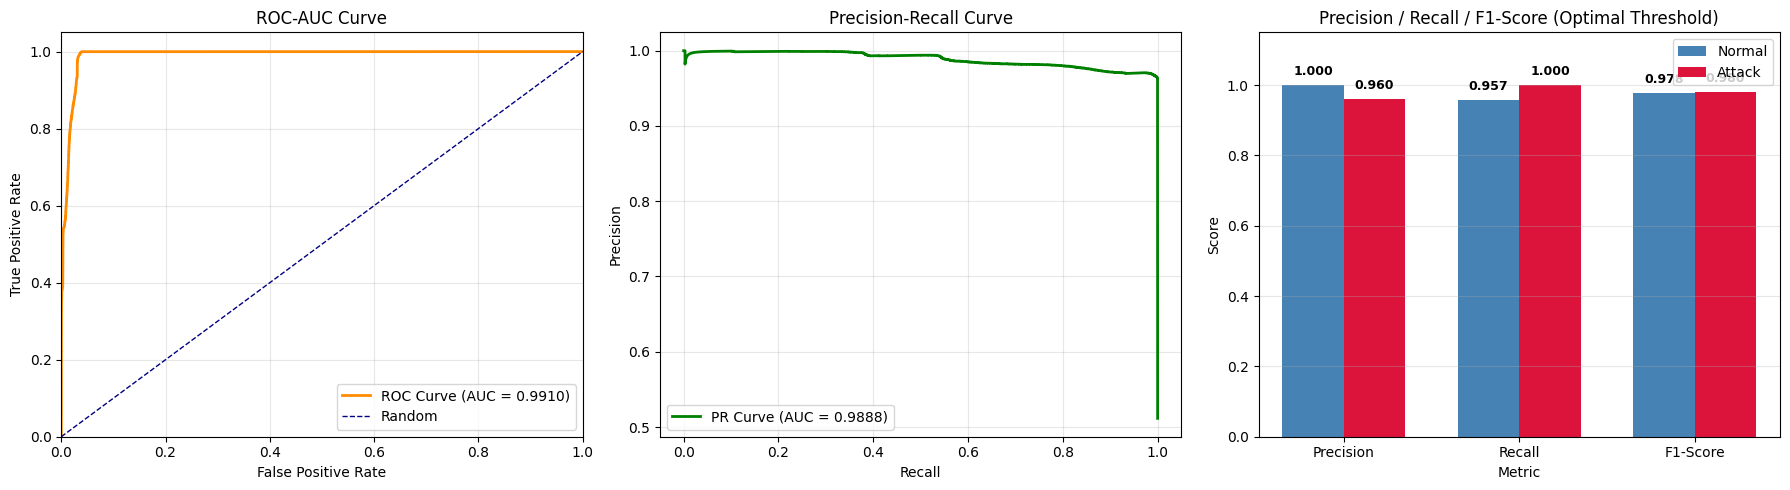

ROC-AUC: 0.9910
PR-AUC:  0.9888

Kelas       Precision     Recall   F1-Score
------------------------------------------
Normal         1.0000     0.9569     0.9780
Attack         0.9605     1.0000     0.9798

Plot disimpan ke roc_pr_metrics.png


In [14]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: ROC-AUC Curve ---
ax = axes[0]
fpr, tpr, _ = roc_curve(y_true, test_errors)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC Curve (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], color="navy", linewidth=1, linestyle="--", label="Random")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-AUC Curve")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_true, test_errors)
pr_auc_val = auc(rec, prec)
ax.plot(rec, prec, color="green", linewidth=2, label=f"PR Curve (AUC = {pr_auc_val:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

# --- Plot 3: Bar Chart Precision, Recall, F1-Score per kelas ---
ax = axes[2]
# Gunakan optimal threshold
prec_normal = precision_score(y_true, y_pred, pos_label=0)
rec_normal = recall_score(y_true, y_pred, pos_label=0)
f1_normal = f1_score(y_true, y_pred, pos_label=0)

prec_attack = precision_score(y_true, y_pred, pos_label=1)
rec_attack = recall_score(y_true, y_pred, pos_label=1)
f1_attack = f1_score(y_true, y_pred, pos_label=1)

x_pos = np.arange(3)
width = 0.35
bars1 = ax.bar(x_pos - width / 2, [prec_normal, rec_normal, f1_normal], width, label="Normal", color="steelblue")
bars2 = ax.bar(x_pos + width / 2, [prec_attack, rec_attack, f1_attack], width, label="Attack", color="crimson")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1-Score (Optimal Threshold)")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax.set_ylim([0, 1.15])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Tampilkan nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("roc_pr_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC:  {pr_auc_val:.4f}")
print(f"\n{'Kelas':<10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"{'-'*42}")
print(f"{'Normal':<10} {prec_normal:>10.4f} {rec_normal:>10.4f} {f1_normal:>10.4f}")
print(f"{'Attack':<10} {prec_attack:>10.4f} {rec_attack:>10.4f} {f1_attack:>10.4f}")
print(f"\nPlot disimpan ke roc_pr_metrics.png")

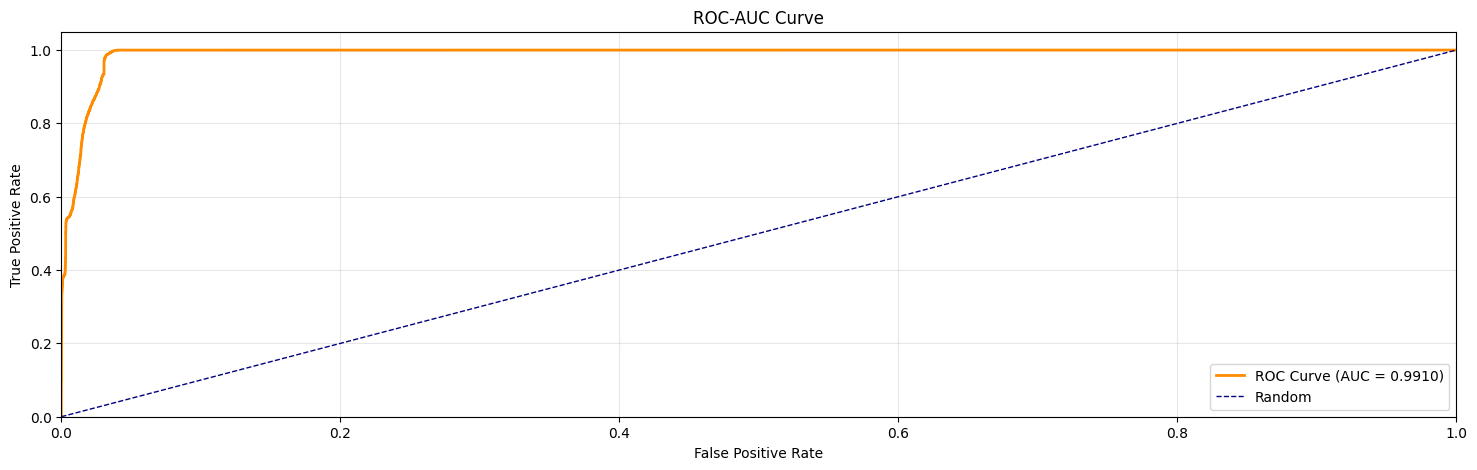

In [15]:
fig, ax = plt.subplots(figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_true, test_errors)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC Curve (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], color="navy", linewidth=1, linestyle="--", label="Random")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-AUC Curve")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

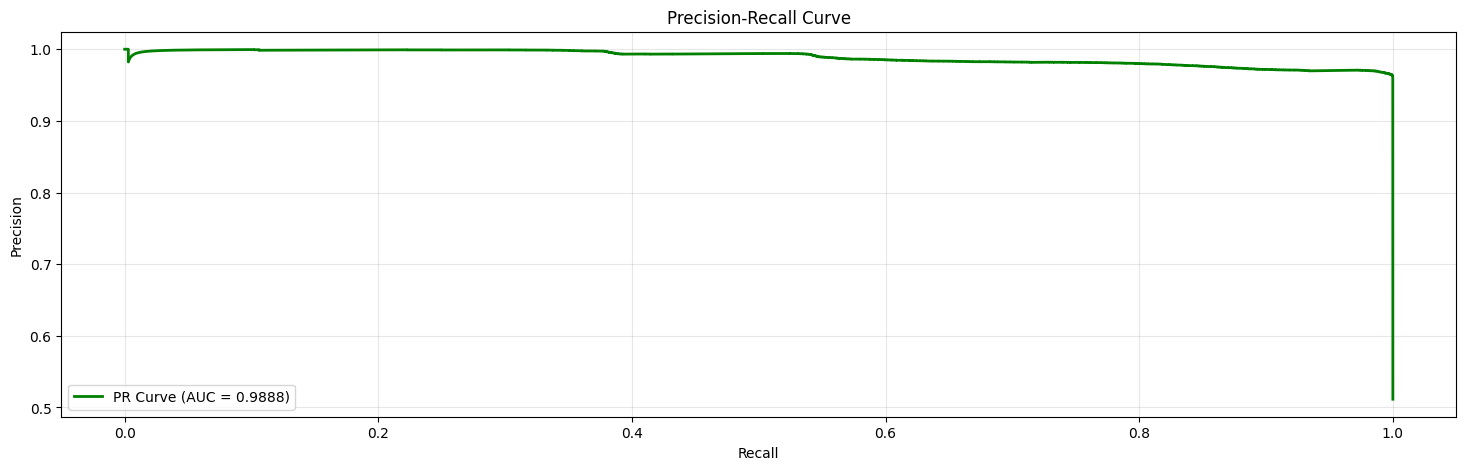

In [16]:
fig, ax = plt.subplots(figsize=(18, 5))
prec, rec, _ = precision_recall_curve(y_true, test_errors)
pr_auc_val = auc(rec, prec)
ax.plot(rec, prec, color="green", linewidth=2, label=f"PR Curve (AUC = {pr_auc_val:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)


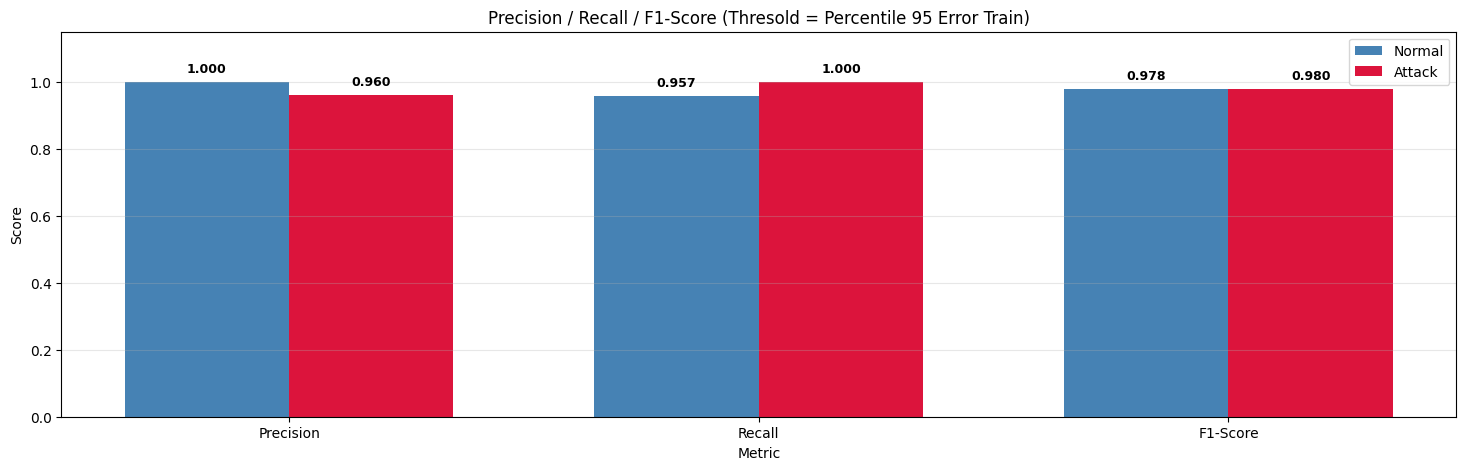

In [17]:
fig, ax = plt.subplots(figsize=(18, 5))
prec_normal = precision_score(y_true, y_pred, pos_label=0)
rec_normal = recall_score(y_true, y_pred, pos_label=0)
f1_normal = f1_score(y_true, y_pred, pos_label=0)

prec_attack = precision_score(y_true, y_pred, pos_label=1)
rec_attack = recall_score(y_true, y_pred, pos_label=1)
f1_attack = f1_score(y_true, y_pred, pos_label=1)

x_pos = np.arange(3)
width = 0.35
bars1 = ax.bar(x_pos - width / 2, [prec_normal, rec_normal, f1_normal], width, label="Normal", color="steelblue")
bars2 = ax.bar(x_pos + width / 2, [prec_attack, rec_attack, f1_attack], width, label="Attack", color="crimson")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1-Score (Thresold = Percentile 95 Error Train)")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax.set_ylim([0, 1.15])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Tampilkan nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

## 15. Save Model (Checkpoint Lengkap)

In [18]:
import pickle

# Simpan checkpoint lengkap: model, scaler, hyperparams, threshold
checkpoint = {
    "model_state_dict": model.state_dict(),
    "scaler": scaler,
    "hyperparams": {
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "seq_len": SEQ_LEN,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
    },
    "threshold": threshold,
    "best_percentile": best_percentile,
    "threshold_results": threshold_results,  # Semua hasil evaluasi threshold
    "best_test_loss": best_test_loss,
    "roc_auc": roc_auc_val,
    "feature_columns": FEATURE_COLUMNS,
    "history": history,
}

torch.save(checkpoint, "lstm_autoencoder_checkpoint.pth")

# Simpan juga scaler terpisah (untuk deployment)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model disimpan:")
print(f"  ✓ lstm_autoencoder_checkpoint.pth (checkpoint lengkap)")
print(f"  ✓ best_lstm_autoencoder.pth (state_dict saja)")
print(f"  ✓ scaler.pkl (StandardScaler)")
print(f"  ✓ Threshold terbaik: Percentile {best_percentile} = {threshold:.6f}")
print(f"\nUntuk load kembali:")
print(f"  checkpoint = torch.load('lstm_autoencoder_checkpoint.pth')")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")

Model disimpan:
  ✓ lstm_autoencoder_checkpoint.pth (checkpoint lengkap)
  ✓ best_lstm_autoencoder.pth (state_dict saja)
  ✓ scaler.pkl (StandardScaler)
  ✓ Threshold terbaik: Percentile 95.0 = 0.527213

Untuk load kembali:
  checkpoint = torch.load('lstm_autoencoder_checkpoint.pth')
  model.load_state_dict(checkpoint['model_state_dict'])


## 16. Ringkasan

In [19]:
print("=" * 60)
print("RINGKASAN MODEL LSTM-AUTOENCODER")
print("=" * 60)
print(f"Dataset:          CSE-CICIDS-2018 (02-14-2018.csv)")
print(f"Fitur:            {len(FEATURE_COLUMNS)} kolom")
print(f"Sequence Length:  {SEQ_LEN}")
print(f"Hidden Dim:       {HIDDEN_DIM}")
print(f"Latent Dim:       {LATENT_DIM}")
print(f"LSTM Layers:      {NUM_LAYERS}")
print(f"Parameters:       {total_params:,}")
print(f"Epochs:           {NUM_EPOCHS}")
print(f"Best Test Loss:   {best_test_loss:.6f}")
print(f"ROC AUC:          {roc_auc:.4f}")
print(f"Best Threshold:   Percentile {best_percentile} = {threshold:.6f}")
print(f"Device:           {device}")
print(f"\n--- Semua Threshold yang Diuji ---")
for r in threshold_results:
    marker = " ★" if r["Percentile"] == best_percentile else ""
    print(f"  P{r['Percentile']:<5} thr={r['Threshold']:.6f}  "
          f"F1(N)={r['F1(Normal)']:.4f}  F1(A)={r['F1(Attack)']:.4f}  "
          f"F1(Macro)={r['F1(Macro)']:.4f}{marker}")
print("=" * 60)

RINGKASAN MODEL LSTM-AUTOENCODER
Dataset:          CSE-CICIDS-2018 (02-14-2018.csv)
Fitur:            10 kolom
Sequence Length:  10
Hidden Dim:       64
Latent Dim:       32
LSTM Layers:      2
Parameters:       113,834
Epochs:           30
Best Test Loss:   4.028411
ROC AUC:          0.9910
Best Threshold:   Percentile 95.0 = 0.527213
Device:           cpu

--- Semua Threshold yang Diuji ---
  P80    thr=0.267082  F1(N)=0.9012  F1(A)=0.9209  F1(Macro)=0.9110
  P85    thr=0.308326  F1(N)=0.9308  F1(A)=0.9418  F1(Macro)=0.9363
  P90    thr=0.370903  F1(N)=0.9563  F1(A)=0.9615  F1(Macro)=0.9589
  P95    thr=0.527213  F1(N)=0.9780  F1(A)=0.9798  F1(Macro)=0.9789 ★
  P99    thr=1.631318  F1(N)=0.8237  F1(A)=0.7492  F1(Macro)=0.7865
  P99.5  thr=2.572453  F1(N)=0.8047  F1(A)=0.7023  F1(Macro)=0.7535
